# 05 — Esperimento supplementare: quantità e omogeneità dei dati

La pipeline principale addestra su due blocchi di protocollo, per 316 finestre. È poco, e
la domanda naturale è se il limite delle prestazioni stia lì.

La domanda però ha due versioni che vengono spesso confuse, e questo esperimento le tiene
separate.

**Quantità.** Aggiungere altre celle allo stesso protocollo migliora le prestazioni?
È la domanda sul numero di esempi.

**Omogeneità.** A parità di numero di celle, conviene che siano tutte dello stesso
protocollo o che coprano condizioni diverse? È la domanda su quali esempi, e ha
implicazioni opposte per il test in distribuzione e per quello fuori: più varietà dovrebbe
aiutare la robustezza e potrebbe costare precisione sul protocollo di riferimento.

Le due variano insieme se non si sta attenti: aggiungere celle a caso aumenta sia il numero
sia la varietà, e l'effetto misurato sarebbe la somma dei due. Il disegno che segue le
incrocia.

**In coda**, una verifica separata: un Transformer è applicabile a questa scala di dati?

**Input:** `data/processed/battery_cycles.csv` e, se disponibile,
`data/processed/battery_cycles_extra.csv`, entrambi prodotti dal notebook 01.

**Output**

| percorso | contenuto |
|---|---|
| `results/tables/05_scaling_metriche.csv` | metriche per numero di blocchi, composizione e seme |
| `results/tables/05_scaling_riepilogo.csv` | mediane per configurazione |
| `results/tables/05_transformer_confronto.csv` | confronto con l'architettura ricorrente |
| `results/figures/05_*.png` | curve di apprendimento e confronto |


## 1. Configurazione


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    pass


def find_project_root():
    candidate_paths = [
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/drive/My Drive/SoH_Neural_Tracker"),
        Path.cwd(), *Path.cwd().parents,
    ]
    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
for cartella in [TABLES_DIR, FIGURES_DIR]:
    cartella.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE, ORIZZONTE = 10, 1
LIMITE_SCOSTAMENTO = 5.0

VARIABILI = [
    "soh_feature",
    "voltage_mean_rel", "voltage_min_rel", "voltage_max_rel", "voltage_std_rel",
    "temperature_mean_rise_rel", "temperature_max_rise_rel", "temperature_std_rel",
    "discharge_time_rel", "num_measurements_rel",
]

# Gli insiemi di valutazione restano quelli della pipeline principale: cambiare anche
# quelli renderebbe i risultati non confrontabili con il notebook 03.
VALIDAZIONE = ["B0007_p1"]
TEST_ID = ["B0018_p1", "B0042_p1", "B0043_p1"]
TEST_OOD = ["B0029_p1", "B0030_p1", "B0031_p1", "B0032_p1", "B0042_p2", "B0043_p2"]
BLOCCHI_RISERVATI = set(VALIDAZIONE + TEST_ID + TEST_OOD)

print("Radice del progetto:", PROJECT_ROOT)


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker


In [2]:
percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"
percorso_extra = DATA_PROCESSED / "battery_cycles_extra.csv"
assert percorso_cicli.exists(), "manca battery_cycles.csv: esegui prima 01_preprocessing"

df = pd.read_csv(percorso_cicli)
df["origine"] = "progetto"

if percorso_extra.exists():
    extra = pd.read_csv(percorso_extra)
    extra["origine"] = "aggiuntiva"
    colonne_comuni = [c for c in df.columns if c in extra.columns]
    df = pd.concat([df[colonne_comuni], extra[colonne_comuni]], ignore_index=True)
    print(f"Celle aggiuntive caricate: {extra.battery_id.nunique()}")
else:
    print("battery_cycles_extra.csv non presente.")
    print("L'esperimento userà i soli blocchi del progetto: il braccio sull'omogeneità")
    print("non sarà eseguibile e l'intervallo di numerosità sarà più stretto.")

df["soh_feature"] = df["soh"]
assenti = [c for c in VARIABILI if c not in df.columns]
assert not assenti, f"colonne assenti: {assenti}"

print(f"\nBlocchi totali: {df.protocol_block.nunique()}   cicli: {len(df)}")


Celle aggiuntive caricate: 12

Blocchi totali: 28   cicli: 2043


## 2. I due bacini di blocchi

Il **protocollo di riferimento** è quello delle celle di addestramento della pipeline
principale: 24 °C e circa 2 A. Un blocco è considerato dello stesso protocollo se rientra
in una tolleranza dichiarata su entrambi i parametri.

Il bacino **omogeneo** contiene i blocchi allo stesso protocollo; quello **eterogeneo** i
blocchi a protocollo diverso. I blocchi usati per la validazione e per i test sono esclusi
da entrambi: usarli in addestramento renderebbe le metriche prive di significato.


In [3]:
TOLLERANZA_TEMPERATURA = 5.0   # °C
TOLLERANZA_CORRENTE = 0.5      # A

profilo = (df[df.is_valid].groupby("protocol_block")
           .agg(battery_id=("battery_id", "first"),
                origine=("origine", "first"),
                ambiente_c=("ambient_temperature", "first"),
                corrente_a=("current_mean", lambda s: float(s.abs().median())),
                n_validi=("soh", "size"))
           .reset_index())

riferimento = profilo[profilo.protocol_block.isin(["B0005_p1", "B0006_p1"])]
AMBIENTE_RIF = float(riferimento.ambiente_c.median())
CORRENTE_RIF = float(riferimento.corrente_a.median())

profilo["stesso_protocollo"] = (
    (profilo.ambiente_c - AMBIENTE_RIF).abs() <= TOLLERANZA_TEMPERATURA
) & ((profilo.corrente_a - CORRENTE_RIF).abs() <= TOLLERANZA_CORRENTE)

# Un blocco entra in addestramento solo se ha abbastanza cicli per produrre finestre.
profilo["utilizzabile"] = (
    (profilo.n_validi >= WINDOW_SIZE + ORIZZONTE + 5)
    & ~profilo.protocol_block.isin(BLOCCHI_RISERVATI))

display(profilo.round(2))

BACINO_OMOGENEO = sorted(profilo[profilo.utilizzabile & profilo.stesso_protocollo]
                         .protocol_block)
BACINO_ETEROGENEO = sorted(profilo[profilo.utilizzabile & ~profilo.stesso_protocollo]
                           .protocol_block)

print(f"\nProtocollo di riferimento: {CORRENTE_RIF:.1f} A, {AMBIENTE_RIF:.0f} °C")
print(f"Bacino omogeneo:   {len(BACINO_OMOGENEO)} blocchi")
print(f"Bacino eterogeneo: {len(BACINO_ETEROGENEO)} blocchi")

# I dieci blocchi del progetto sono tutti impegnati: due in addestramento e gli altri
# negli insiemi di valutazione. Senza le celle aggiuntive non resta nulla da aggiungere,
# e l'esperimento non ha materia.
assert len(BACINO_OMOGENEO) > len(["B0005_p1", "B0006_p1"]) or BACINO_ETEROGENEO, (
    "nessun blocco disponibile oltre a quelli già impegnati nella pipeline principale.\n"
    "Serve data/processed/battery_cycles_extra.csv, prodotto dalla sezione sulle celle "
    "aggiuntive del notebook 01. Se il file non esiste, rilancia il notebook 01: la "
    "cella di raccolta copia in data/original/selected_batteries tutte le celle "
    "presenti negli archivi NASA, non solo le dieci del progetto."
)


,protocol_block,battery_id,origine,ambiente_c,corrente_a,n_validi,stesso_protocollo,utilizzabile
0,B0005_p1,B0005,progetto,24.0,1.82,168,True,True
1,B0006_p1,B0006,progetto,24.0,1.75,168,True,True
2,B0007_p1,B0007,progetto,24.0,1.90,168,True,False
3,B0018_p1,B0018,progetto,24.0,1.82,132,True,False
4,B0025_p1,B0025,aggiuntiva,24.0,1.06,28,False,True
5,B0026_p1,B0026,aggiuntiva,24.0,1.05,28,False,True
6,B0027_p1,B0027,aggiuntiva,24.0,1.06,28,False,True
7,B0028_p1,B0028,aggiuntiva,24.0,1.00,28,False,True
8,B0029_p1,B0029,progetto,43.0,3.92,40,False,False
9,B0030_p1,B0030,progetto,43.0,3.77,40,False,False



Protocollo di riferimento: 1.8 A, 24 °C
Bacino omogeneo:   6 blocchi
Bacino eterogeneo: 9 blocchi


## 3. Il disegno dell'esperimento

Due bracci che condividono la stessa base, così che a parità di numerosità cambi soltanto
la composizione.

- **Braccio omogeneo:** si parte dai due blocchi della pipeline principale e si aggiungono
  blocchi dello stesso protocollo.
- **Braccio eterogeneo:** stessa base, stessa numerosità, ma i blocchi aggiunti vengono dal
  bacino a protocollo diverso.

Gli insiemi sono **annidati**: la configurazione con $k+1$ blocchi contiene tutti quelli
della configurazione con $k$. Se ogni configurazione estraesse blocchi a caso in modo
indipendente, la differenza fra due punti della curva mescolerebbe l'effetto della
numerosità con quello di *quali* blocchi sono capitati.

L'ordine di aggiunta è fissato una volta sola con un seme dichiarato: è un'estrazione, e
con pochi blocchi disponibili la curva dipende anche da quale ordine è uscito. È un limite
dell'esperimento e va riportato.


In [4]:
BASE = ["B0005_p1", "B0006_p1"]
SEME_ORDINE = 0

rng = np.random.default_rng(SEME_ORDINE)


def coda(bacino):
    """Blocchi del bacino non già nella base, in ordine casuale ma fissato."""
    restanti = [b for b in bacino if b not in BASE]
    return [restanti[i] for i in rng.permutation(len(restanti))]


coda_omogenea = coda(BACINO_OMOGENEO)
coda_eterogenea = coda(BACINO_ETEROGENEO)

configurazioni = []
for etichetta, sequenza in [("omogenea", coda_omogenea), ("eterogenea", coda_eterogenea)]:
    for k in range(len(sequenza) + 1):
        blocchi = BASE + sequenza[:k]
        configurazioni.append({"composizione": etichetta, "n_blocchi": len(blocchi),
                               "blocchi": blocchi})

configurazioni = pd.DataFrame(configurazioni)
# La configurazione di base è la stessa nei due bracci: si tiene una volta sola.
configurazioni = configurazioni.drop_duplicates(
    subset=["n_blocchi", "composizione"]).reset_index(drop=True)
mascherata = (configurazioni.n_blocchi == len(BASE)) & (configurazioni.composizione == "eterogenea")
configurazioni = configurazioni[~mascherata].reset_index(drop=True)

display(configurazioni.assign(blocchi=configurazioni.blocchi.apply(", ".join)))


,composizione,n_blocchi,blocchi
0,omogenea,2,"B0005_p1, B0006_p1"
1,omogenea,3,"B0005_p1, B0006_p1, B0036_p1"
2,omogenea,4,"B0005_p1, B0006_p1, B0036_p1, B0033_p1"
3,omogenea,5,"B0005_p1, B0006_p1, B0036_p1, B0033_p1, B0034_p1"
4,omogenea,6,"B0005_p1, B0006_p1, B0036_p1, B0033_p1, B0034_..."
5,eterogenea,3,"B0005_p1, B0006_p1, B0038_p2"
6,eterogenea,4,"B0005_p1, B0006_p1, B0038_p2, B0040_p2"
7,eterogenea,5,"B0005_p1, B0006_p1, B0038_p2, B0040_p2, B0041_p1"
8,eterogenea,6,"B0005_p1, B0006_p1, B0038_p2, B0040_p2, B0041_..."
9,eterogenea,7,"B0005_p1, B0006_p1, B0038_p2, B0040_p2, B0041_..."


## 4. Costruzione dei dati per configurazione

La normalizzazione va **ristimata per ogni configurazione**, sulle celle di addestramento
di quella configurazione e su nessun'altra. Riusare uno scaler stimato altrove farebbe
entrare nel confronto informazione che quella configurazione non possiede, e le curve non
misurerebbero più solo l'effetto dei dati.

Il bersaglio è la variazione del SoH, come nella pipeline principale.


In [5]:
from sklearn.preprocessing import StandardScaler

da_normalizzare = [c for c in VARIABILI if c != "soh_feature"]


def prepara(blocchi_train):
    """Normalizza sui blocchi di addestramento indicati e costruisce le finestre."""
    train_valido = df[df.protocol_block.isin(blocchi_train) & df.is_valid]
    scaler = StandardScaler().fit(train_valido[da_normalizzare])

    scalato = df.copy()
    scalato[da_normalizzare] = np.clip(
        scaler.transform(df[da_normalizzare]), -LIMITE_SCOSTAMENTO, LIMITE_SCOSTAMENTO)

    def finestre(blocchi):
        X, y, ultimo = [], [], []
        for blocco in blocchi:
            gruppo = scalato[(scalato.protocol_block == blocco) & scalato.is_valid]
            gruppo = gruppo.sort_values("discharge_cycle")
            numerazione = gruppo.discharge_cycle.to_numpy()
            apre = np.ones(len(gruppo), dtype=bool)
            apre[1:] = np.diff(numerazione) != 1
            for _, tratto in gruppo.groupby(np.cumsum(apre)):
                valori = tratto[VARIABILI].to_numpy()
                soh = tratto["soh"].to_numpy()
                for i in range(len(tratto) - WINDOW_SIZE - ORIZZONTE + 1):
                    fine = i + WINDOW_SIZE - 1
                    X.append(valori[i:i + WINDOW_SIZE])
                    y.append(soh[fine + ORIZZONTE])
                    ultimo.append(soh[fine])
        return (np.asarray(X, "float32"), np.asarray(y, "float32"),
                np.asarray(ultimo, "float32"))

    return {"train": finestre(blocchi_train), "validation": finestre(VALIDAZIONE),
            "test_id": finestre(TEST_ID), "test_ood": finestre(TEST_OOD)}


def rmse(vero, previsto):
    return float(np.sqrt(np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)))


def skill_score(vero, previsto, baseline):
    mse_modello = np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)
    mse_baseline = np.mean((np.asarray(baseline) - np.asarray(vero)) ** 2)
    return float(1.0 - mse_modello / mse_baseline) if mse_baseline else np.nan


prova = prepara(BASE)
for nome, (X, y, l) in prova.items():
    print(f"{nome:12s} {len(y):4d} finestre   persistenza RMSE {rmse(y, l):.5f}")


train         316 finestre   persistenza RMSE 0.00989
validation    158 finestre   persistenza RMSE 0.00675
test_id       172 finestre   persistenza RMSE 0.01103
test_ood      150 finestre   persistenza RMSE 0.00804


## 5. Il modello e il ciclo dell'esperimento

Una sola architettura, tenuta fissa: la domanda riguarda i dati, non la rete. Tre semi per
configurazione, perché con questa variabilità una singola esecuzione non distinguerebbe
l'effetto dei dati dal caso.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

ARCHITETTURA = "GRU"
UNITA, UNITA_DENSA, DROPOUT = 64, 32, 0.2
SEMI = [0, 1, 2]
EPOCHE, BATCH_SIZE, PAZIENZA = 150, 32, 20


def costruisci_ricorrente(forma, bias_iniziale):
    ingresso = layers.Input(shape=forma)
    strato = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM,
              "GRU": layers.GRU}[ARCHITETTURA]
    x = strato(UNITA)(ingresso)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(UNITA_DENSA, activation="relu")(x)
    return models.Model(ingresso, layers.Dense(
        1, bias_initializer=tf.keras.initializers.Constant(bias_iniziale))(x))


def addestra(costruttore, dati, semi=SEMI):
    Xtr, ytr, ltr = dati["train"]
    Xva, yva, lva = dati["validation"]
    variazione_train, variazione_val = ytr - ltr, yva - lva

    righe = []
    for seme in semi:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seme)

        modello = costruttore(Xtr.shape[1:], float(variazione_train.mean()))
        modello.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        modello.fit(Xtr, variazione_train, validation_data=(Xva, variazione_val),
                    epochs=EPOCHE, batch_size=BATCH_SIZE, verbose=0,
                    callbacks=[callbacks.EarlyStopping(monitor="val_loss",
                                                       patience=PAZIENZA,
                                                       restore_best_weights=True)])

        for nome, (X, y, l) in dati.items():
            previsto = modello.predict(X, verbose=0).reshape(-1) + l
            righe.append({"seme": seme, "insieme": nome, "n_finestre": len(y),
                          "RMSE": rmse(y, previsto),
                          "SS": skill_score(y, previsto, l),
                          "parametri": int(modello.count_params())})
    return pd.DataFrame(righe)


In [7]:
risultati = []
for riga in configurazioni.itertuples():
    dati = prepara(riga.blocchi)
    tabella = addestra(costruisci_ricorrente, dati)
    tabella["composizione"] = riga.composizione
    tabella["n_blocchi"] = riga.n_blocchi
    tabella["n_finestre_train"] = len(dati["train"][1])
    risultati.append(tabella)

    mediana = tabella[tabella.insieme == "test_id"].RMSE.median()
    mediana_ood = tabella[tabella.insieme == "test_ood"].RMSE.median()
    print(f"{riga.composizione:11s} {riga.n_blocchi} blocchi   "
          f"{len(dati['train'][1]):4d} finestre   "
          f"RMSE test_id {mediana:.5f}   test_ood {mediana_ood:.5f}")

scaling = pd.concat(risultati, ignore_index=True)
scaling.to_csv(TABLES_DIR / "05_scaling_metriche.csv", index=False)


omogenea    2 blocchi    316 finestre   RMSE test_id 0.02177   test_ood 0.01741
omogenea    3 blocchi    503 finestre   RMSE test_id 0.01251   test_ood 0.01051
omogenea    4 blocchi    674 finestre   RMSE test_id 0.01938   test_ood 0.00998
omogenea    5 blocchi    860 finestre   RMSE test_id 0.01538   test_ood 0.00852
omogenea    6 blocchi    885 finestre   RMSE test_id 0.01627   test_ood 0.00809
eterogenea  3 blocchi    341 finestre   RMSE test_id 0.01493   test_ood 0.01883
eterogenea  4 blocchi    364 finestre   RMSE test_id 0.01172   test_ood 0.01355
eterogenea  5 blocchi    421 finestre   RMSE test_id 0.24754   test_ood 0.05600
eterogenea  6 blocchi    439 finestre   RMSE test_id 0.19505   test_ood 0.05684
eterogenea  7 blocchi    457 finestre   RMSE test_id 0.25609   test_ood 0.04546
eterogenea  8 blocchi    475 finestre   RMSE test_id 0.36914   test_ood 0.07413
eterogenea  9 blocchi    500 finestre   RMSE test_id 0.36290   test_ood 0.07843
eterogenea  10 blocchi    518 finestre  

In [8]:
riepilogo = (scaling.groupby(["composizione", "n_blocchi", "insieme"])
             .agg(n_finestre_train=("n_finestre_train", "first"),
                  RMSE=("RMSE", "median"), RMSE_min=("RMSE", "min"),
                  RMSE_max=("RMSE", "max"), SS=("SS", "median"))
             .reset_index())

for insieme in ["test_id", "test_ood"]:
    print(f"\n{insieme}")
    display(riepilogo[riepilogo.insieme == insieme]
            .sort_values(["composizione", "n_blocchi"]).round(5))

riepilogo.to_csv(TABLES_DIR / "05_scaling_riepilogo.csv", index=False)



test_id


,composizione,n_blocchi,insieme,n_finestre_train,RMSE,RMSE_min,RMSE_max,SS
0,eterogenea,3,test_id,341,0.01493,0.01414,0.01693,-0.83395
4,eterogenea,4,test_id,364,0.01172,0.01107,0.02820,-0.12956
8,eterogenea,5,test_id,421,0.24754,0.01295,0.39554,-503.05304
12,eterogenea,6,test_id,439,0.19505,0.02513,0.31360,-311.96210
16,eterogenea,7,test_id,457,0.25609,0.17482,2.04051,-538.49231
20,eterogenea,8,test_id,475,0.36914,0.26206,1.88868,-1119.90369
24,eterogenea,9,test_id,500,0.36290,0.35288,3.28995,-1082.31995
28,eterogenea,10,test_id,518,0.34505,0.33038,0.37374,-978.38538
32,eterogenea,11,test_id,533,0.28708,0.22506,0.44019,-676.92902
36,omogenea,2,test_id,316,0.02177,0.01107,0.02834,-2.89757



test_ood


,composizione,n_blocchi,insieme,n_finestre_train,RMSE,RMSE_min,RMSE_max,SS
1,eterogenea,3,test_ood,341,0.01883,0.01435,0.02037,-4.48069
5,eterogenea,4,test_ood,364,0.01355,0.00835,0.01721,-1.83785
9,eterogenea,5,test_ood,421,0.05600,0.01518,0.05990,-47.49001
13,eterogenea,6,test_ood,439,0.05684,0.01183,0.07262,-48.95558
17,eterogenea,7,test_ood,457,0.04546,0.02728,0.06061,-30.94391
21,eterogenea,8,test_ood,475,0.07413,0.01755,0.08846,-83.96569
25,eterogenea,9,test_ood,500,0.07843,0.04512,0.08784,-94.10567
29,eterogenea,10,test_ood,518,0.04850,0.02324,0.06825,-35.37062
33,eterogenea,11,test_ood,533,0.05497,0.02911,0.07630,-45.72231
37,omogenea,2,test_ood,316,0.01741,0.00837,0.02662,-3.68344


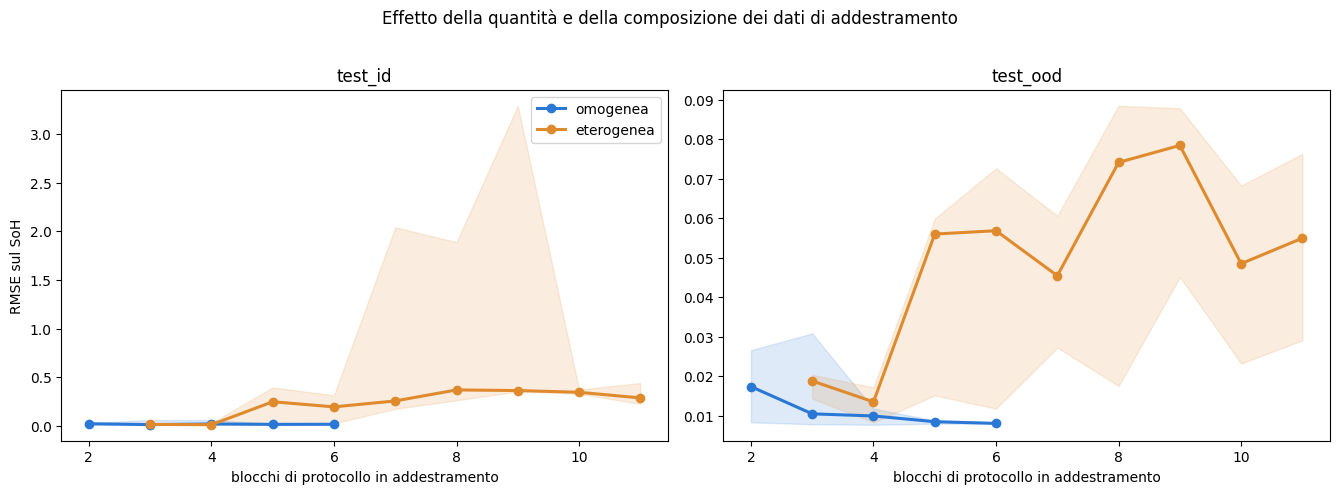

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)

for ax, insieme in zip(axes, ["test_id", "test_ood"]):
    for composizione, colore in [("omogenea", "#2a78d6"), ("eterogenea", "#e08a2e")]:
        curva = (riepilogo[(riepilogo.insieme == insieme)
                           & (riepilogo.composizione == composizione)]
                 .sort_values("n_blocchi"))
        if not len(curva):
            continue
        ax.plot(curva.n_blocchi, curva.RMSE, "-o", color=colore, lw=2.2, ms=6,
                label=composizione)
        ax.fill_between(curva.n_blocchi, curva.RMSE_min, curva.RMSE_max,
                        color=colore, alpha=0.15)
    ax.set_xlabel("blocchi di protocollo in addestramento")
    ax.set_title(insieme)

axes[0].set_ylabel("RMSE sul SoH")
axes[0].legend()
fig.suptitle("Effetto della quantità e della composizione dei dati di addestramento",
             y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_scaling_curve.png", dpi=200, bbox_inches="tight")
plt.show()


In [10]:
print("Lettura dell'esperimento\n")
for insieme in ["test_id", "test_ood"]:
    omogenea = (riepilogo[(riepilogo.insieme == insieme)
                          & (riepilogo.composizione == "omogenea")]
                .sort_values("n_blocchi"))
    if len(omogenea) >= 2:
        primo, ultimo = omogenea.iloc[0], omogenea.iloc[-1]
        variazione = ultimo.RMSE / primo.RMSE - 1
        print(f"{insieme}: da {int(primo.n_blocchi)} a {int(ultimo.n_blocchi)} blocchi "
              f"({int(primo.n_finestre_train)} → {int(ultimo.n_finestre_train)} finestre), "
              f"RMSE {variazione:+.1%}")

confrontabili = riepilogo.groupby(["insieme", "n_blocchi"]).composizione.nunique()
confrontabili = confrontabili[confrontabili > 1].reset_index()
if len(confrontabili):
    print("\nA parità di numero di blocchi, omogenea contro eterogenea:")
    for riga in confrontabili.itertuples():
        coppia = riepilogo[(riepilogo.insieme == riga.insieme)
                           & (riepilogo.n_blocchi == riga.n_blocchi)]
        valori = coppia.set_index("composizione").RMSE
        print(f"  {riga.insieme:9s} {int(riga.n_blocchi)} blocchi   "
              f"omogenea {valori.get('omogenea', np.nan):.5f}   "
              f"eterogenea {valori.get('eterogenea', np.nan):.5f}")
else:
    print("\nNessuna numerosità è disponibile in entrambe le composizioni:")
    print("il confronto sull'omogeneità non è eseguibile con i blocchi presenti.")


Lettura dell'esperimento

test_id: da 2 a 6 blocchi (316 → 885 finestre), RMSE -25.3%
test_ood: da 2 a 6 blocchi (316 → 885 finestre), RMSE -53.5%

A parità di numero di blocchi, omogenea contro eterogenea:
  test_id   3 blocchi   omogenea 0.01251   eterogenea 0.01493
  test_id   4 blocchi   omogenea 0.01938   eterogenea 0.01172
  test_id   5 blocchi   omogenea 0.01538   eterogenea 0.24754
  test_id   6 blocchi   omogenea 0.01627   eterogenea 0.19505
  test_ood  3 blocchi   omogenea 0.01051   eterogenea 0.01883
  test_ood  4 blocchi   omogenea 0.00998   eterogenea 0.01355
  test_ood  5 blocchi   omogenea 0.00852   eterogenea 0.05600
  test_ood  6 blocchi   omogenea 0.00809   eterogenea 0.05684
  train     3 blocchi   omogenea 0.02154   eterogenea 0.01132
  train     4 blocchi   omogenea 0.02933   eterogenea 0.01091
  train     5 blocchi   omogenea 0.02978   eterogenea 0.87712
  train     6 blocchi   omogenea 0.02911   eterogenea 0.85898
  validation 3 blocchi   omogenea 0.00788   etero

## 6. Un Transformer è applicabile a questa scala?

Domanda separata dalla precedente, e la ragione per porla è che il Transformer è
l'architettura di riferimento per le sequenze e la sua assenza dal confronto va motivata.

L'argomento non è il numero di parametri — si misura, ed è confrontabile — ma il **vincolo
strutturale**. Una rete ricorrente ha l'ordine dei passi incorporato nella propria forma:
elabora la sequenza un elemento alla volta e lo stato accumula il passato. L'attenzione non
ha nulla di tutto questo: ogni passo vede tutti gli altri simultaneamente, e la nozione di
ordine deve essere fornita dall'esterno con una codifica di posizione e poi *appresa* dai
dati.

Quando gli esempi sono centinaia, una struttura che va appresa è uno svantaggio rispetto a
una che è data. La verifica consiste nel costruire il Transformer più piccolo sensato,
addestrarlo sulle stesse configurazioni e confrontarlo con l'architettura ricorrente a
parità di dati.


In [11]:
TESTE, DIMENSIONE_MODELLO, DIMENSIONE_FF = 2, 32, 64


def codifica_posizionale(lunghezza, dimensione):
    """Codifica sinusoidale: fornisce alla rete la nozione di ordine che la
    ricorrenza ha per costruzione."""
    posizioni = np.arange(lunghezza)[:, None]
    indici = np.arange(dimensione)[None, :]
    angoli = posizioni / np.power(10000.0, (2 * (indici // 2)) / dimensione)
    codifica = np.zeros((lunghezza, dimensione), dtype="float32")
    codifica[:, 0::2] = np.sin(angoli[:, 0::2])
    codifica[:, 1::2] = np.cos(angoli[:, 1::2])
    return tf.constant(codifica)


def costruisci_transformer(forma, bias_iniziale):
    lunghezza, n_variabili = forma
    ingresso = layers.Input(shape=forma)

    x = layers.Dense(DIMENSIONE_MODELLO)(ingresso)
    x = x + codifica_posizionale(lunghezza, DIMENSIONE_MODELLO)

    attenzione = layers.MultiHeadAttention(
        num_heads=TESTE, key_dim=DIMENSIONE_MODELLO // TESTE, dropout=DROPOUT)(x, x)
    x = layers.LayerNormalization()(x + attenzione)

    avanti = layers.Dense(DIMENSIONE_FF, activation="relu")(x)
    avanti = layers.Dense(DIMENSIONE_MODELLO)(avanti)
    x = layers.LayerNormalization()(x + avanti)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(UNITA_DENSA, activation="relu")(x)
    return models.Model(ingresso, layers.Dense(
        1, bias_initializer=tf.keras.initializers.Constant(bias_iniziale))(x))


forma_prova = prova["train"][0].shape[1:]
parametri = {
    ARCHITETTURA: costruisci_ricorrente(forma_prova, 0.0).count_params(),
    "Transformer": costruisci_transformer(forma_prova, 0.0).count_params(),
}
for nome, n in parametri.items():
    print(f"{nome:12s} {n:6d} parametri")
print("\nI due modelli sono confrontabili per dimensione: la differenza attesa non")
print("viene dalla capacità ma da quanta struttura ciascuno deve apprendere dai dati.")


GRU           16705 parametri
Transformer    9985 parametri

I due modelli sono confrontabili per dimensione: la differenza attesa non
viene dalla capacità ma da quanta struttura ciascuno deve apprendere dai dati.


In [12]:
righe_transformer = []
configurazioni_omogenee = configurazioni[configurazioni.composizione == "omogenea"]

for riga in configurazioni_omogenee.itertuples():
    dati = prepara(riga.blocchi)
    for nome_modello, costruttore in [(ARCHITETTURA, costruisci_ricorrente),
                                      ("Transformer", costruisci_transformer)]:
        tabella = addestra(costruttore, dati)
        tabella["modello"] = nome_modello
        tabella["n_blocchi"] = riga.n_blocchi
        tabella["n_finestre_train"] = len(dati["train"][1])
        righe_transformer.append(tabella)

    sotto = pd.concat(righe_transformer[-2:])
    sotto = sotto[sotto.insieme == "test_id"]
    valori = sotto.groupby("modello").RMSE.median()
    print(f"{riga.n_blocchi} blocchi   " +
          "   ".join(f"{k} {v:.5f}" for k, v in valori.items()))

transformer = pd.concat(righe_transformer, ignore_index=True)
transformer.to_csv(TABLES_DIR / "05_transformer_confronto.csv", index=False)


2 blocchi   GRU 0.02177   Transformer 0.09949
3 blocchi   GRU 0.01251   Transformer 0.03337
4 blocchi   GRU 0.01938   Transformer 0.02165
5 blocchi   GRU 0.01538   Transformer 0.01667
6 blocchi   GRU 0.01627   Transformer 0.01199


,modello,n_blocchi,insieme,RMSE,SS,parametri,n_finestre_train
0,GRU,2,test_id,0.02177,-2.89757,16705,316
1,GRU,2,test_ood,0.01741,-3.68344,16705,316
2,GRU,3,test_id,0.01251,-0.28795,16705,503
3,GRU,3,test_ood,0.01051,-0.70740,16705,503
4,GRU,4,test_id,0.01938,-2.08946,16705,674
5,GRU,4,test_ood,0.00998,-0.53885,16705,674
6,GRU,5,test_id,0.01538,-0.94563,16705,860
7,GRU,5,test_ood,0.00852,-0.12224,16705,860
8,GRU,6,test_id,0.01627,-1.17703,16705,885
9,GRU,6,test_ood,0.00809,-0.01116,16705,885


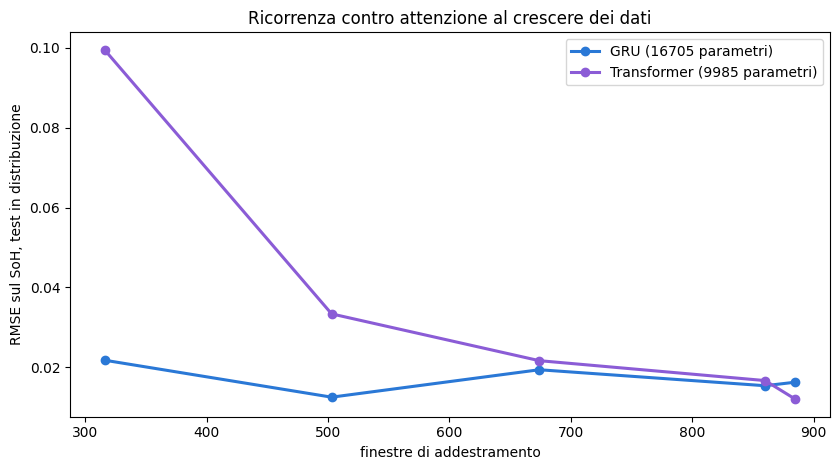

In [13]:
confronto = (transformer[transformer.insieme.isin(["test_id", "test_ood"])]
             .groupby(["modello", "n_blocchi", "insieme"])
             .agg(RMSE=("RMSE", "median"), SS=("SS", "median"),
                  parametri=("parametri", "first"),
                  n_finestre_train=("n_finestre_train", "first"))
             .reset_index())
display(confronto.round(5))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for nome_modello, colore in [(ARCHITETTURA, "#2a78d6"), ("Transformer", "#8b5cd6")]:
    curva = (confronto[(confronto.modello == nome_modello)
                       & (confronto.insieme == "test_id")]
             .sort_values("n_finestre_train"))
    ax.plot(curva.n_finestre_train, curva.RMSE, "-o", color=colore, lw=2.2, ms=6,
            label=f"{nome_modello} ({int(curva.parametri.iloc[0])} parametri)")

ax.set_xlabel("finestre di addestramento")
ax.set_ylabel("RMSE sul SoH, test in distribuzione")
ax.set_title("Ricorrenza contro attenzione al crescere dei dati")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_transformer_confronto.png", dpi=200, bbox_inches="tight")
plt.show()


In [14]:
finale = (confronto[confronto.insieme == "test_id"]
          .sort_values("n_finestre_train").groupby("modello").tail(1)
          .set_index("modello"))

print("Conclusione sull'architettura\n")
if len(finale) == 2:
    ricorrente = float(finale.loc[ARCHITETTURA, "RMSE"])
    attenzione = float(finale.loc["Transformer", "RMSE"])
    n = int(finale.n_finestre_train.max())
    print(f"Con {n} finestre di addestramento: {ARCHITETTURA} {ricorrente:.5f}, "
          f"Transformer {attenzione:.5f}.")
    if attenzione > ricorrente:
        print(f"Il Transformer è peggiore del {attenzione / ricorrente - 1:.0%}, pur "
              f"avendo un numero di parametri confrontabile.")
        print("L'interpretazione è quella anticipata: a questa scala di dati il vincolo")
        print("strutturale della ricorrenza è un vantaggio, perché fornisce gratis una")
        print("nozione di ordine che l'attenzione deve ricavare dagli esempi.")
    else:
        print("Il Transformer regge il confronto già a questa scala: la sua esclusione")
        print("dal confronto principale andrebbe rivista.")

print()
print("Limiti dell'esperimento")
print("  1. l'ordine di aggiunta dei blocchi è una singola estrazione casuale:")
print(f"     con {len(coda_omogenea)} blocchi disponibili la curva ne dipende")
print("  2. tre semi per configurazione: bastano a vedere un effetto grande, non uno piccolo")
print("  3. gli insiemi di valutazione restano fissi, quindi le curve sono confrontabili")
print("     fra loro ma non con esperimenti che li cambino")


Conclusione sull'architettura

Con 885 finestre di addestramento: GRU 0.01627, Transformer 0.01199.
Il Transformer regge il confronto già a questa scala: la sua esclusione
dal confronto principale andrebbe rivista.

Limiti dell'esperimento
  1. l'ordine di aggiunta dei blocchi è una singola estrazione casuale:
     con 4 blocchi disponibili la curva ne dipende
  2. tre semi per configurazione: bastano a vedere un effetto grande, non uno piccolo
  3. gli insiemi di valutazione restano fissi, quindi le curve sono confrontabili
     fra loro ma non con esperimenti che li cambino
